<a href="https://colab.research.google.com/github/IntroComputationalPhysics-UNT/connecting-to-github-classroom-henry8675309/blob/main/ThermoExam2Comp_prob_(9).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

     Approach:

# Van der Waals Equation and Maxwell Construction

## 1. Van der Waals Equation of State

The van der Waals equation improves the ideal gas law by accounting for intermolecular attraction and the finite size of molecules. It is written as

$$
P = \frac{NkT}{V - Nb} - \frac{aN^2}{V^2}
$$

where

- \(P\) = pressure
- \(V\) = volume
- \(T\) = temperature
- \(N\) = number of particles
- \(k\) = Boltzmann constant
- \(a\) accounts for intermolecular attraction
- \(b\) accounts for the finite molecular size.

---

# 2. Critical Point Derivation

The **critical point** occurs where the liquid and gas phases become indistinguishable. At this point the pressure–volume isotherm has a horizontal inflection point.

Mathematically this occurs when

$$
\left(\frac{\partial P}{\partial V}\right)_T = 0
$$

and

$$
\left(\frac{\partial^2 P}{\partial V^2}\right)_T = 0
$$

Applying these conditions to the van der Waals equation leads to the critical parameters

$$
V_c = 3Nb
$$

$$
P_c = \frac{a}{27b^2}
$$

$$
kT_c = \frac{8a}{27b}
$$

These define the **critical volume, pressure, and temperature** of a van der Waals fluid.

---

# 3. Reduced Variables

To make the equation independent of a particular substance, reduced variables are introduced:

$$
p = \frac{P}{P_c}
$$

$$
v = \frac{V}{V_c}
$$

$$
t = \frac{T}{T_c}
$$

Substituting these into the van der Waals equation produces the **reduced equation of state**

$$
p(v) = \frac{8t}{3v - 1} - \frac{3}{v^2}
$$

This form describes the universal behavior of a van der Waals fluid.

---

# 4. Maxwell Equal Area Construction

For temperatures below the critical temperature (\(t < 1\)), the van der Waals isotherm contains an unphysical oscillating region corresponding to unstable states.

To correct this, the **Maxwell equal-area construction** replaces the oscillating region with a horizontal line corresponding to the vapor pressure \(p_v\).

The equal-area condition is

$$
\int_{v_1}^{v_2} (p_v - p(v))\,dv =
\int_{v_2}^{v_3} (p(v) - p_v)\,dv
$$

where

- \(v_1\) = liquid volume
- \(v_2\) = unstable region
- \(v_3\) = gas volume

This condition ensures that the **Gibbs free energy of the liquid and gas phases are equal**, determining the correct vapor pressure.

---

# 5. Computational Method

The Maxwell construction is implemented numerically by:

1. Solving \(p(v) = p_v\) to find the three volumes \(v_1, v_2, v_3\)

2. Computing the areas

$$
A_1 = \int_{v_1}^{v_2} (p_v - p(v))\,dv
$$

$$
A_2 = \int_{v_2}^{v_3} (p(v) - p_v)\,dv
$$

3. For each reduced temperature t < 1 the vapor pressure pv was determined using
the Maxwell equal area rule so that the two shaded regions satisfy

    A1 = A2

    This ensures thermodynamic equilibrium between liquid and vapor phases.

    This calculation is performed using numerical root-finding and integration.

---

# 6. Phase Diagram

The Maxwell construction is repeated for several reduced temperatures

$$
t = 0.6, 0.8, 0.9, 1.0
$$

This produces the coexistence vapor pressure \(p_v(t)\), which forms the **liquid–gas phase boundary**.

At

$$
t = 1
$$

the system reaches the **critical point**, where the liquid and gas phases merge and the equal-area condition disappears.

    Imports:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

    Defined Variables:

In [ ]:
def pressure(v, t):
    return (8*t)/(3*v - 1) - 3/(v**2)

def gibbs(v, t):
    return -9/(4*v) - t*np.log(3*v - 1) + t/(3*v - 1)

v = np.arange(0.5, 2.6, 0.001)

    (p vs. v) & (g vs. p) @ Different Temps:


Temperature t = 0.6


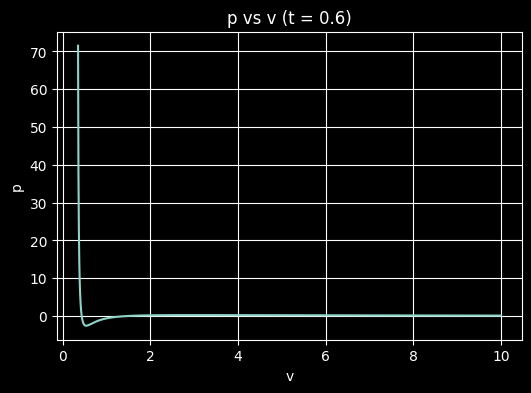

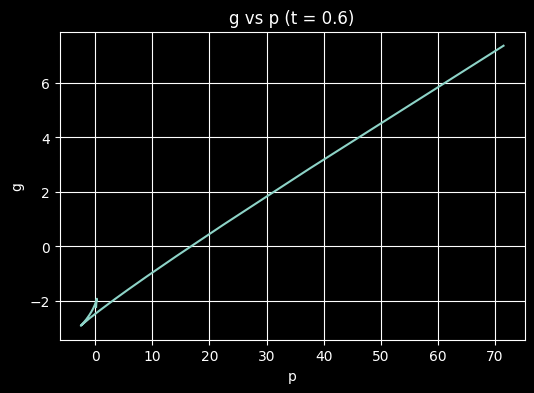


Temperature t = 0.8


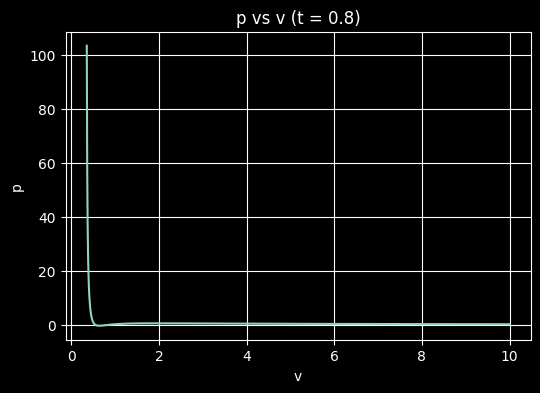

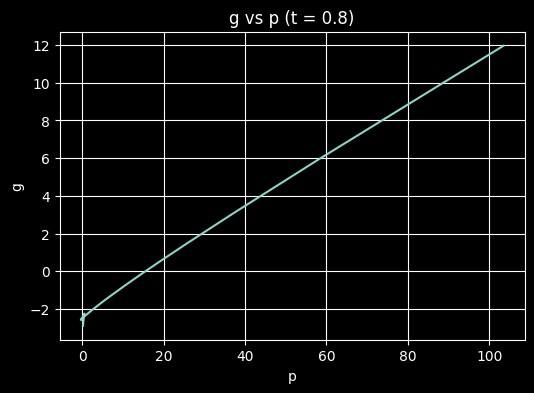


Temperature t = 0.9


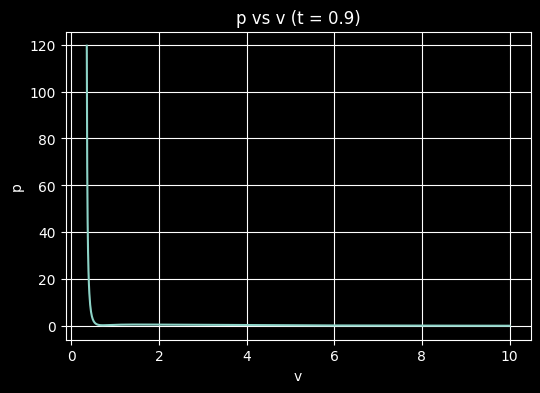

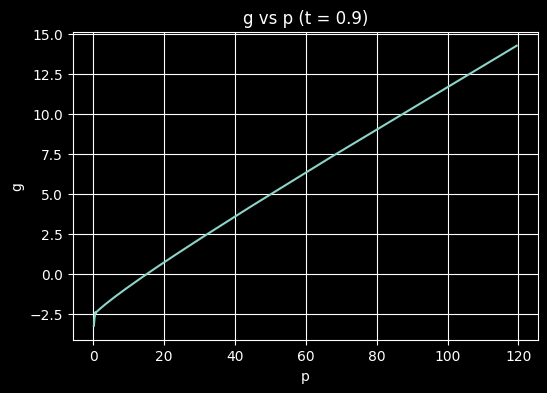


Temperature t = 1.0


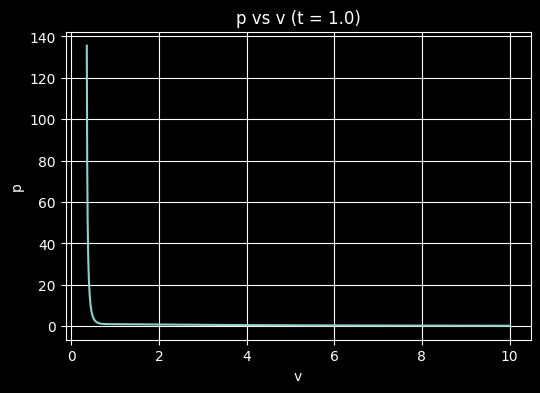

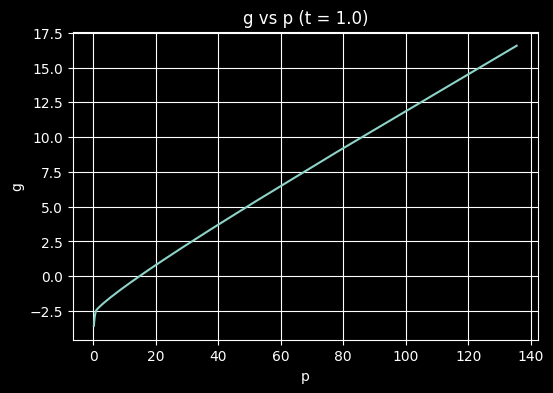


Temperature t = 1.1


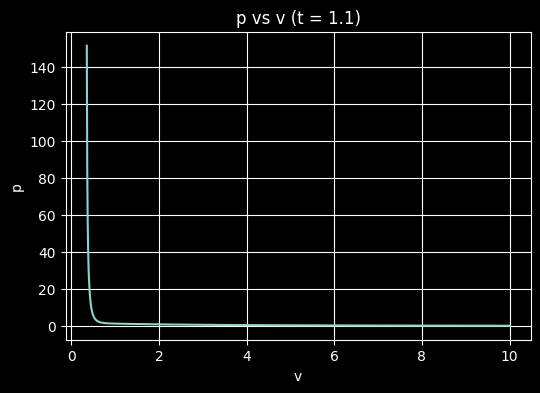

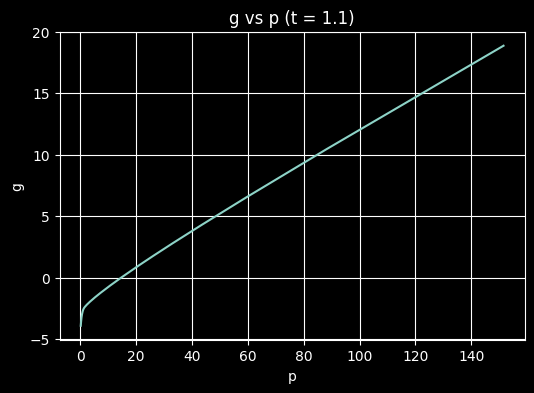

In [ ]:
temps = [0.6, 0.8, 0.9, 1.0, 1.1]

for t in temps:
    print(f"\nTemperature t = {t}")

    p = pressure(v, t)
    g = gibbs(v, t)

    plt.figure(figsize=(6,4))
    plt.plot(v, p)
    plt.xlabel("v")
    plt.ylabel("p")
    plt.title(f"p vs v (t = {t})")
    plt.grid()
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(p, g)
    plt.xlabel("p")
    plt.ylabel("g")
    plt.title(f"g vs p (t = {t})")
    plt.grid()
    plt.show()


     Maxwell construction table & (p vs. v) with Vapor Pressure plots @ Temp:

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import brentq
from scipy.integrate import quad

# Reduced van der Waals pressure
def p_of_v(v, t):
    return (8*t)/(3*v - 1) - 3/(v**2)

# Equation p(v) - pv = 0
def f_root(v, t, pv):
    return p_of_v(v, t) - pv

# Find all real roots of p(v)=pv by scanning
def find_roots(t, pv, vmin=0.34, vmax=30.0, npts=20000):
    vgrid = np.linspace(vmin, vmax, npts)
    fvals = f_root(vgrid, t, pv)
    roots = []

    for i in range(len(vgrid) - 1):
        a, b = vgrid[i], vgrid[i+1]
        fa, fb = fvals[i], fvals[i+1]

        if not np.isfinite(fa) or not np.isfinite(fb):
            continue

        if fa == 0:
            roots.append(a)
        elif fa * fb < 0:
            try:
                r = brentq(lambda v: f_root(v, t, pv), a, b)
                if len(roots) == 0 or abs(r - roots[-1]) > 1e-4:
                    roots.append(r)
            except ValueError:
                pass

    return roots

# Maxwell area difference A1 - A2
def area_difference(pv, t):
    roots = find_roots(t, pv)

    if len(roots) < 3:
        return None

    v1, v2, v3 = roots[:3]

    A1, _ = quad(lambda v: pv - p_of_v(v, t), v1, v2)
    A2, _ = quad(lambda v: p_of_v(v, t) - pv, v2, v3)

    return A1 - A2

# Automatically find a valid bracket for pv
def find_valid_bracket(t, pv_low, pv_high, nscan=200):
    pv_values = np.linspace(pv_low, pv_high, nscan)
    good = []

    for pv in pv_values:
        val = area_difference(pv, t)
        if val is not None and np.isfinite(val):
            good.append((pv, val))

    for i in range(len(good) - 1):
        pv1, f1 = good[i]
        pv2, f2 = good[i+1]
        if f1 == 0:
            return pv1, pv1
        if f1 * f2 < 0:
            return pv1, pv2

    return None

# Solve Maxwell construction
def solve_maxwell(t, pv_low, pv_high):
    bracket = find_valid_bracket(t, pv_low, pv_high)

    if bracket is None:
        return {
            "t": t,
            "pv": np.nan,
            "v1": np.nan,
            "v2": np.nan,
            "v3": np.nan,
            "A1": np.nan,
            "A2": np.nan
        }

    a, b = bracket

    if a == b:
        pv = a
    else:
        pv = brentq(lambda pv: area_difference(pv, t), a, b)

    roots = find_roots(t, pv)
    v1, v2, v3 = roots[:3]

    A1, _ = quad(lambda v: pv - p_of_v(v, t), v1, v2)
    A2, _ = quad(lambda v: p_of_v(v, t) - pv, v2, v3)

    return {
        "t": t,
        "pv": pv,
        "v1": v1,
        "v2": v2,
        "v3": v3,
        "A1": A1,
        "A2": A2
    }

# Run for your temperatures
results = []
results.append(solve_maxwell(0.6, 0.05, 0.20))
results.append(solve_maxwell(0.8, 0.25, 0.50))
results.append(solve_maxwell(0.9, 0.55, 0.75))

# Critical point
results.append({
    "t": 1.0,
    "pv": 1.0,
    "v1": 1.0,
    "v2": 1.0,
    "v3": 1.0,
    "A1": 0.0,
    "A2": 0.0
})

# Supercritical
results.append({
    "t": 1.1,
    "pv": np.nan,
    "v1": np.nan,
    "v2": np.nan,
    "v3": np.nan,
    "A1": np.nan,
    "A2": np.nan
})

results_df = pd.DataFrame(results)
print(results_df)

     t        pv        v1        v2         v3        A1        A2
0  0.6  0.086869  0.432609  1.590671  16.728531  1.087110  1.087110
1  0.8  0.383362  0.517409  1.208273   4.172457  0.254632  0.254632
2  0.9  0.646998  0.603402  1.090527   2.348842  0.061753  0.061753
3  1.0  1.000000  1.000000  1.000000   1.000000  0.000000  0.000000
4  1.1       NaN       NaN       NaN        NaN       NaN       NaN



Temperature t = 0.6


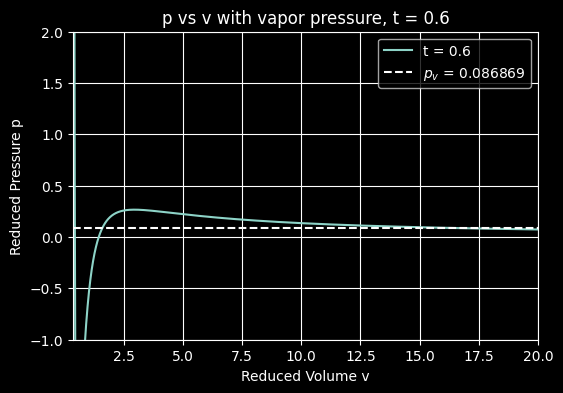


Temperature t = 0.8


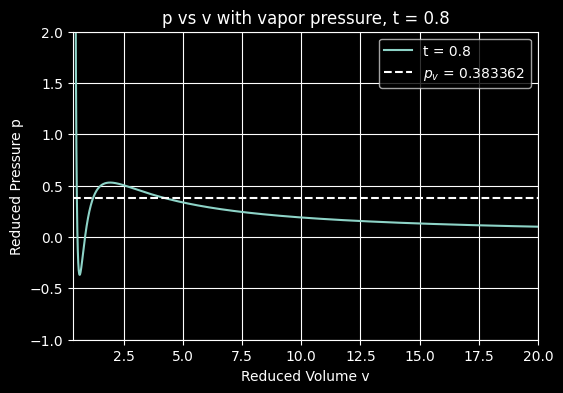


Temperature t = 0.9


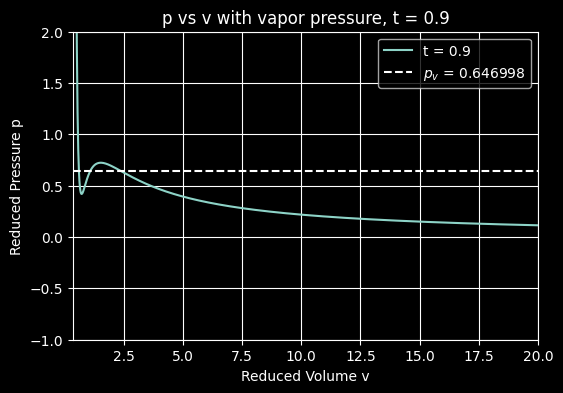


Temperature t = 1.0


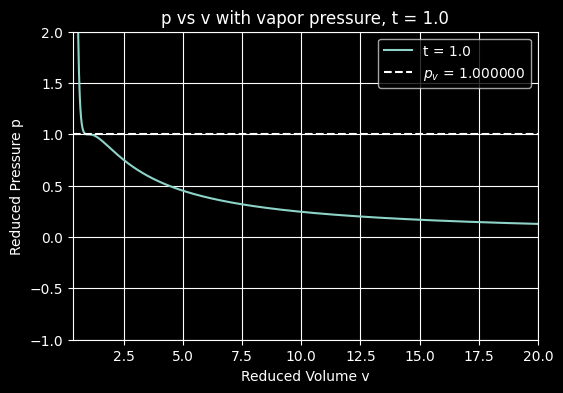

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def pressure(v, t):
    return (8*t)/(3*v - 1) - 3/(v**2)

v = np.linspace(0.35, 20, 2000)

pv_values = {
    0.6: 0.086869,
    0.8: 0.383362,
    0.9: 0.646998,
    1.0: 1.000000

}

temps = [0.6, 0.8, 0.9, 1.0]

for t in temps:
    print(f"\nTemperature t = {t}")
    p = pressure(v, t)
    pv = pv_values[t]

    plt.figure(figsize=(6,4))
    plt.plot(v, p, label=f"t = {t}")
    plt.axhline(pv, linestyle="--", label=f"$p_v$ = {pv:.6f}")
    plt.xlabel("Reduced Volume v")
    plt.ylabel("Reduced Pressure p")
    plt.title(f"p vs v with vapor pressure, t = {t}")
    plt.xlim(0.35, 20)
    plt.ylim(-1, 2)
    plt.grid(True)
    plt.legend()
    plt.show()

    Final Phase Diagram plot @ Temps:

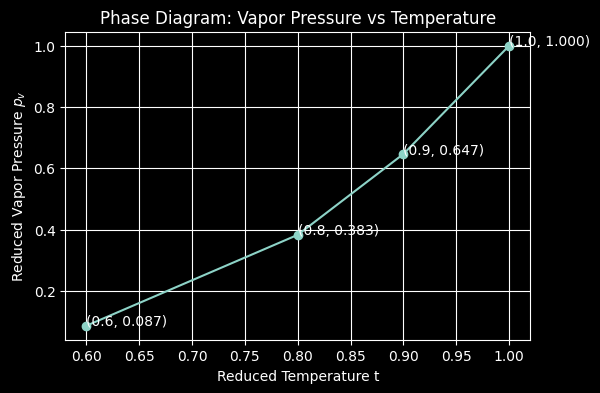

In [ ]:
import matplotlib.pyplot as plt

phase_df = results_df.dropna(subset=["pv"]).copy()

plt.figure(figsize=(6,4))
plt.plot(phase_df["t"], phase_df["pv"], marker="o")

for _, row in phase_df.iterrows():
    plt.text(row["t"], row["pv"], f"({row['t']:.1f}, {row['pv']:.3f})")

plt.xlabel("Reduced Temperature t")
plt.ylabel("Reduced Vapor Pressure $p_v$")
plt.title("Phase Diagram: Vapor Pressure vs Temperature")
plt.grid(True)
plt.show()

    Single plot of (p vs. v) @ Temps:

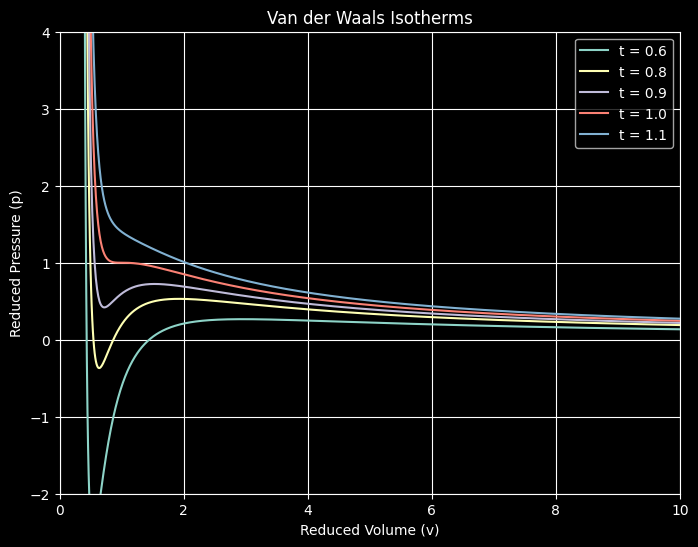

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def p_vdw(v, t):
    return (8*t)/(3*v - 1) - 3/(v**2)

v = np.linspace(0.35, 10, 1000)

temps = [0.6, 0.8, 0.9, 1.0, 1.1]

plt.figure(figsize=(8,6))

for t in temps:
    plt.plot(v, p_vdw(v, t), label=f"t = {t}")

plt.xlabel("Reduced Volume (v)")
plt.ylabel("Reduced Pressure (p)")
plt.title("Van der Waals Isotherms")
plt.legend()
plt.ylim(-2,4)
plt.xlim(0,10)
plt.grid(True)

plt.show()